<a href="https://colab.research.google.com/github/ItaloSSilva/tf2-time-series-analysis/blob/main/Projeto_TF2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# O Impacto da Comunidade e a Crise dos Bots no Team Fortress 2: **Uma análise de séries temporais sobre retenção de jogadores e intervenções da desenvolvedora.**

## 1. O Problema de Negócio
O Team Fortress 2 (TF2), um dos jogos multiplayer mais longevos do mercado, sofreu nos últimos anos com uma infestação massiva de contas automatizadas (bots) que degradaram severamente a experiência nos servidores casuais. O objetivo deste projeto é analisar o impacto real dessa crise na retenção de jogadores e investigar se as campanhas massivas da comunidade nas redes sociais (#SaveTF2 e #FixTF2) tiveram correlação direta com as ondas de banimento executadas pela desenvolvedora (Valve).

## 2. Preparação dos Dados
Para esta análise de séries temporais, foram consolidadas duas bases de dados:
* **Série Temporal de Jogadores:** Dados históricos de jogadores simultâneos no Steam, extraídos do *SteamDB* (AppID 440).
* **Tabela Dimensional de Eventos:** Um dataset criado manualmente contendo os marcos temporais das manifestações da comunidade e das intervenções técnicas da Valve.

## 3. Processamento e Limpeza
Os dados brutos extraídos geralmente apresentam ruídos e formatos não otimizados para cálculos temporais. Nesta etapa, utilizamos a biblioteca `Pandas` para:
1. Converter a coluna de datas do formato *String* para o padrão *Datetime*.
2. Definir a variável temporal como o Índice (*Index*) do DataFrame, permitindo o fatiamento cronológico.
3. Tratar flutuações diárias normais calculando uma Média Móvel (*Rolling Average*) de 7 dias, o que nos permite isolar a tendência real de retenção e visualizar quedas anômalas com mais clareza.

In [14]:
import pandas as pd

# 1. Carregue o arquivo CSV exportado
# (Substitua o nome do arquivo caso seja diferente)
df = pd.read_csv('steamdb_chart_440.csv', delimiter=';')

# Exibe as primeiras linhas para confirmar o nome exato das colunas
# Geralmente o SteamDB usa 'DateTime' e 'Players'
print("Antes da conversão:")
display(df.head())

# 2. Converta a coluna de datas de String para Datetime
# O parâmetro utc=True ajuda a padronizar o fuso horário, caso o SteamDB inclua essa info
df['DateTime'] = pd.to_datetime(df['DateTime'], utc=True)

# 3. Defina a coluna de data como o Índice (Index) do DataFrame
df.set_index('DateTime', inplace=True)

# 4. Ordene o índice cronologicamente (boa prática em séries temporais)
df.sort_index(inplace=True)

# 5. Calcule a Média Móvel (Rolling Average)
# Isso cria uma nova coluna suavizando os picos diários normais para focar nas tendências reais
df['Players_MA_7D'] = df['Players'].rolling(window=7).mean()

print("\nDepois do tratamento:")
display(df.head())

Antes da conversão:


,DateTime,Players,Average Players
0,2007-09-19 00:00:00,9553.0,NaN
1,2007-09-20 00:00:00,NaN,NaN
2,2007-09-21 00:00:00,5118.0,NaN
3,2007-09-22 00:00:00,4616.0,NaN
4,2007-09-23 00:00:00,NaN,NaN



Depois do tratamento:


,Players,Average Players,Players_MA_7D
DateTime,,,
2007-09-19 00:00:00+00:00,9553.0,NaN,NaN
2007-09-20 00:00:00+00:00,NaN,NaN,NaN
2007-09-21 00:00:00+00:00,5118.0,NaN,NaN
2007-09-22 00:00:00+00:00,4616.0,NaN,NaN
2007-09-23 00:00:00+00:00,NaN,NaN,NaN


In [15]:
# Filtra os dados apenas para o período crítico dos banimentos de verão de 2024
crise_2024 = df.loc['2024-05-01':'2024-08-31']
display(crise_2024)

,Players,Average Players,Players_MA_7D
DateTime,,,
2024-05-01 00:00:00+00:00,66035.0,60527.0,75419.000000
2024-05-02 00:00:00+00:00,75261.0,60746.0,75654.428571
2024-05-03 00:00:00+00:00,72220.0,66846.0,75147.714286
2024-05-04 00:00:00+00:00,78907.0,71814.0,74993.428571
2024-05-05 00:00:00+00:00,80135.0,70543.0,74842.571429
...,...,...,...
2024-08-27 00:00:00+00:00,63760.0,55921.0,64425.428571
2024-08-28 00:00:00+00:00,49653.0,43409.0,63923.571429
2024-08-29 00:00:00+00:00,64896.0,50148.0,63714.000000


In [19]:
import pandas as pd

# Carrega o CSV de eventos
df_eventos = pd.read_csv('tf2_eventos.csv', delimiter='\t')

# Converte a coluna Data para o formato Datetime
df_eventos['Data'] = pd.to_datetime(df_eventos['Data'], utc=True, dayfirst=True)

display(df_eventos)

,Data,Evento,Categoria
0,2022-05-26 00:00:00+00:00,#SaveTF2,Protesto
1,2022-06-22 00:00:00+00:00,Primeira Onda de Bans,Acao da Valve
2,2024-06-03 00:00:00+00:00,#FixTF2,Protesto
3,2024-06-27 00:00:00+00:00,Banimento de Verao,Acao da Valve


## 4. Análise e Visualização
Com a base temporal estruturada e a média móvel calculada, cruzamos a linha do tempo principal com a nossa tabela dimensional de eventos.

Através da combinação das bibliotecas `Matplotlib` e `Seaborn`, gerei um gráfico analítico delimitando o eixo X a partir de 2019 para focar exclusivamente no período crítico da crise. A plotagem destaca a diferença entre a média de retenção e os picos de bots, demarcando visualmente a dinâmica de ação e reação entre a Comunidade (Vermelho) e a Desenvolvedora (Azul).

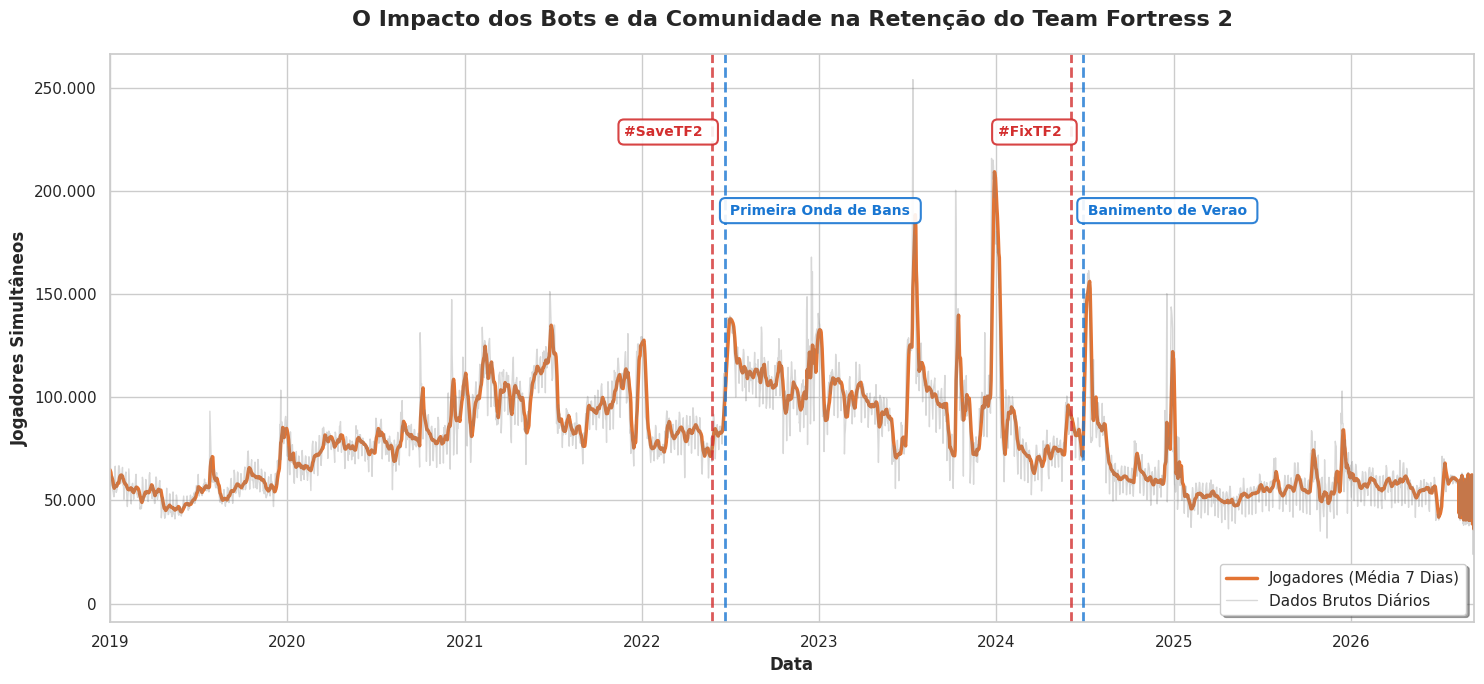

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configuração de Estilo
sns.set_theme(style="whitegrid") # Fundo com grade sutil para facilitar a leitura

# Cria a figura e o eixo com uma proporção "widescreen"
fig, ax = plt.subplots(figsize=(15, 7))

# 2. Plotagem dos Jogadores
# Linha principal com a Média Móvel (suavizada) usando um tom de Laranja do TF2
sns.lineplot(
    data=df,
    x=df.index,
    y='Players_MA_7D',
    color='#E37433',
    linewidth=2.5,
    label='Jogadores (Média 7 Dias)',
    ax=ax
)

# Plota os dados brutos diários no fundo, com transparência (alpha)
sns.lineplot(
    data=df,
    x=df.index,
    y='Players',
    color='grey',
    alpha=0.3,
    linewidth=1,
    label='Dados Brutos Diários',
    ax=ax
)

# 3. Adicionando os Eventos Históricos (O cruzamento de dados)
# Dicionário para colorir Protestos de vermelho e Ações da Valve de azul
cores_eventos = {'Protesto': '#D32F2F', 'Acao da Valve': '#1976D2'}

# O laço (loop) percorre cada linha do seu CSV de eventos
# Definimos duas alturas diferentes no eixo Y (95% e 75% do topo)
alturas_y = [df['Players'].max() * 0.95, df['Players'].max() * 0.75]
contador = 0

for _, row in df_eventos.iterrows():
    data_evento = row['Data']
    nome_evento = row['Evento']
    categoria = row['Categoria']
    cor = cores_eventos.get(categoria, 'black')

    # Desenha a linha vertical pontilhada
    ax.axvline(x=data_evento, color=cor, linestyle='--', linewidth=2, alpha=0.8)

    # Caixa de fundo para destacar o texto e evitar que as linhas o cortem
    estilo_caixa = dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor=cor, linewidth=1.5, alpha=0.9)

    # Alterna a altura (90% e 75% do topo)
    y_pos = df['Players'].max() * (0.90 if contador % 2 == 0 else 0.75)

    # Alterna o alinhamento: o primeiro evento vai para a esquerda da linha, o segundo para a direita
    alinhamento = 'right' if contador % 2 == 0 else 'left'

    ax.text(
        x=data_evento,
        y=y_pos,
        s=f" {nome_evento} " if alinhamento == 'left' else f"{nome_evento}  ",
        color=cor,
        fontsize=10,
        fontweight='bold',
        rotation=0, # Texto na horizontal para leitura rápida
        horizontalalignment=alinhamento,
        verticalalignment='center',
        bbox=estilo_caixa
    )

    contador += 1

# 4. Refinamento Visual
ax.set_title(
    "O Impacto dos Bots e da Comunidade na Retenção do Team Fortress 2",
    fontsize=16, fontweight='bold', pad=20
)
ax.set_xlabel("Data", fontsize=12, fontweight='bold')
ax.set_ylabel("Jogadores Simultâneos", fontsize=12, fontweight='bold')

# Remove a notação científica do eixo Y (transforma 100000 em 100.000)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x)).replace(',', '.'))
)

# Posiciona a legenda no canto inferior direito
plt.legend(loc='lower right', frameon=True, shadow=True)

# Ajusta as margens para nada ficar cortado na hora de exportar
plt.tight_layout()

# Limita o eixo X para focar no período crítico da crise dos bots
ax.set_xlim(pd.to_datetime('2019-01-01', utc=True), df.index.max())

# Exibe o gráfico
plt.show()

## 5. Conclusões e Insights
A visualização dos dados nos permite tirar três conclusões analíticas fundamentais sobre o ecossistema do jogo:

* **A Verdadeira Escala dos Bots:** A queda vertical drástica no número de jogadores logo após o "Banimento de Verão" (Junho/Julho de 2024) revela a verdadeira proporção de contas automatizadas. A base de jogadores despencou de forma antinatural de um dia para o outro, provando que os picos anteriores não representavam engajamento humano, mas sim inflação artificial.
* **Causalidade entre Comunidade e Empresa:** O gráfico demonstra uma forte correlação temporal entre as ações da comunidade e as reações da Valve. As grandes ondas de banimento (linhas pontilhadas azuis) ocorreram poucas semanas após as mobilizações massivas globais da hashtag (linhas pontilhadas vermelhas).
* **Retenção Orgânica e Estabilização:** Após a limpeza sistêmica dos servidores no meio de 2024, a média móvel de jogadores encontrou um novo platô. Embora os números brutos sejam menores que os de 2023, essa nova linha de tendência representa, pela primeira vez em anos, a verdadeira base de retenção orgânica do produto.